# 07 - Slab DaT-SPECT, self-normalization y registro multi-plantilla

Este nodo es independiente de los resultados del nodo 06 y reutiliza solamente los derivados privados del nodo 04. Implementa:

- crop físico a **2 mm isotrópicos** y slab axial de **12 mm** (seis muestras);
- ROI física estriatal independiente de la etiqueta, con recentrado de captación acotado a 10 mm;
- self-normalization $\hat{x}=\sqrt{d}\,x/\lVert x\rVert_2$ dentro de esa ROI, sin fondo occipital;
- comparación excluyente entre lateralidad canonizada y flip aleatorio;
- blur y ruido correlacionado fuertes expresados en milímetros (`M≈2.5`, `P≈0.9`);
- cuatro objetivos auxiliares: caudado/putamen derecho e izquierdo;
- **930 variables regionales**, con imputación, selector, scaler y PCA ajustados dentro de cada fold;
- registro multi-plantilla fold-safe con prototipos independientes de la etiqueta;
- búsqueda Optuna con tres folds y evaluación congelada de finalistas con cinco folds.

Fuentes principales: [Buddenkotte & Buchert 2024](https://doi.org/10.2967/jnumed.124.267570), [Zhou & Tagare 2021](https://arxiv.org/abs/2112.13637), [Apostolova et al. 2023](https://doi.org/10.1186/s40658-023-00544-9). El registro implementado es una aproximación acotada en PyTorch, no una reproducción exacta de SPM12.


In [1]:
from __future__ import annotations

import os
import sys
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from modeling.cnn.io import RunLock
from modeling.dat_spect_v2 import (
    ExperimentConfig,
    ModelConfig,
    MultiTaskDaTClassifier,
    prepare_experiment,
    run_final_stage,
    run_search_stage,
)

RUN_ID = os.environ.get("DAT_NODE07_RUN_ID", "dat_spect_slab_v4")
NODE4_PROFILE = os.environ.get("DAT_NODE07_NODE4_PROFILE", "v3")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EXPERIMENT = ExperimentConfig(run_id=RUN_ID)
EXPERIMENT = replace(
    EXPERIMENT,
    data=replace(EXPERIMENT.data, node4_profile=NODE4_PROFILE),
)

display(Markdown(
    f"**Run:** `{RUN_ID}` · **device:** `{DEVICE}` · "
    f"**slab:** `{EXPERIMENT.data.slab_slices}` cortes a "
    f"`{EXPERIMENT.data.output_spacing_mm:g} mm` · "
    f"**features regionales:** `{EXPERIMENT.data.regional_feature_budget}`"
))


**Run:** `dat_spect_slab_v4` · **device:** `cuda` · **slab:** `6` cortes a `2 mm` · **features regionales:** `930`

## 1. Preparación reanudable

Materializa el cache físico base y congela dos manifiestos independientes: tres folds para búsqueda y cinco folds para evaluación. La unidad es el paciente único. `acquisition_family` sólo ayuda a equilibrar la distribución de protocolos y nunca entra al modelo. Además se conserva un split secundario con familias completamente no vistas como prueba de estrés; no sustituye la CV principal porque una familia contiene 460 casos e impide cinco folds de tamaño comparable.


In [2]:
RUN_DIR = PROJECT_ROOT / "outputs" / "private_eda" / "node07_runs" / RUN_ID
with RunLock(RUN_DIR / "prepare.lock"):
    prepared = prepare_experiment(EXPERIMENT, project_root=PROJECT_ROOT)

display(pd.DataFrame({
    "indicador": [
        "Casos",
        "Familias de adquisición",
        "Patológicos",
        "Fondos SBR válidos",
        "Crops base completos",
    ],
    "valor": [
        len(prepared.cohort),
        prepared.cohort["acquisition_family"].nunique(),
        int(prepared.cohort["is_pathologic"].sum()),
        int(prepared.cohort["background_qc_valid"].sum()),
        int(prepared.cohort["base_cache_path"].map(lambda value: Path(value).exists()).sum()),
    ],
}))
display(pd.read_csv(RUN_DIR / "config" / "search_fold_summary.csv"))
display(pd.read_csv(RUN_DIR / "config" / "final_fold_summary.csv"))
display(Markdown("**Prueba de estrés con familias completamente no vistas:**"))
display(pd.read_csv(RUN_DIR / "config" / "family_stress_fold_summary.csv"))


,indicador,valor
0,Casos,1362
1,Familias de adquisición,134
2,Patológicos,747
3,Fondos SBR válidos,249
4,Crops base completos,1362


,fold,n,pathologic,prevalence,families,background_valid_fraction
0,0,454,249,0.548458,66,0.185022
1,1,454,249,0.548458,70,0.185022
2,2,454,249,0.548458,79,0.178414


,fold,n,pathologic,prevalence,families,background_valid_fraction
0,0,273,150,0.549451,59,0.183150
1,1,273,150,0.549451,48,0.183150
2,2,272,149,0.547794,52,0.176471
3,3,272,149,0.547794,53,0.187500
4,4,272,149,0.547794,49,0.183824


**Prueba de estrés con familias completamente no vistas:**

,fold,n,pathologic,prevalence,families,background_valid_fraction
0,0,465,273,0.587097,6,0.002151
1,1,446,237,0.531390,88,0.331839
2,2,451,237,0.525499,40,0.221729


In [3]:
architecture_rows = []
for architecture in EXPERIMENT.architectures:
    model = MultiTaskDaTClassifier(ModelConfig(
        architecture=architecture,
        feature_variant="image_only",
        lateral_strategy="canonical",
        pooling="gmp" if architecture == "slab2d" else "gap_max",
    ))
    architecture_rows.append({
        "arquitectura": architecture,
        "parametros_entrenables": sum(
            parameter.numel() for parameter in model.parameters() if parameter.requires_grad
        ),
        "embedding_imagen": model.config.image_embedding_dim,
        "objetivos_auxiliares_proxy": model.config.auxiliary_dim,
    })
display(pd.DataFrame(architecture_rows))
display(pd.DataFrame({
    "parametro_augmentation": [
        "magnitud M", "probabilidad P", "FWHM blur base (mm)",
        "FWHM ruido correlacionado (mm)", "rotacion maxima (grados)",
    ],
    "valor": [
        EXPERIMENT.train.augmentation.magnitude,
        EXPERIMENT.train.augmentation.probability,
        EXPERIMENT.train.augmentation.blur_base_fwhm_mm,
        EXPERIMENT.train.augmentation.correlated_noise_fwhm_mm,
        EXPERIMENT.train.augmentation.rotation_degrees,
    ],
}))


,arquitectura,parametros_entrenables,embedding_imagen,objetivos_auxiliares_proxy
0,slab2d,177142,128,4
1,2.5d,128822,128,4
2,3d,480406,128,4


,parametro_augmentation,valor
0,magnitud M,2.5
1,probabilidad P,0.9
2,FWHM blur base (mm),"(1.0, 6.0)"
3,FWHM ruido correlacionado (mm),"(5.0, 15.0)"
4,rotacion maxima (grados),2.0


## 2. Auditoría visual de self-normalization, slab y lateralidad

El panel no selecciona casos por etiqueta; toma una muestra reproducible del manifiesto. La fila izquierda conserva la orientación y la derecha canoniza el putamen de menor captación al lado derecho del paciente.


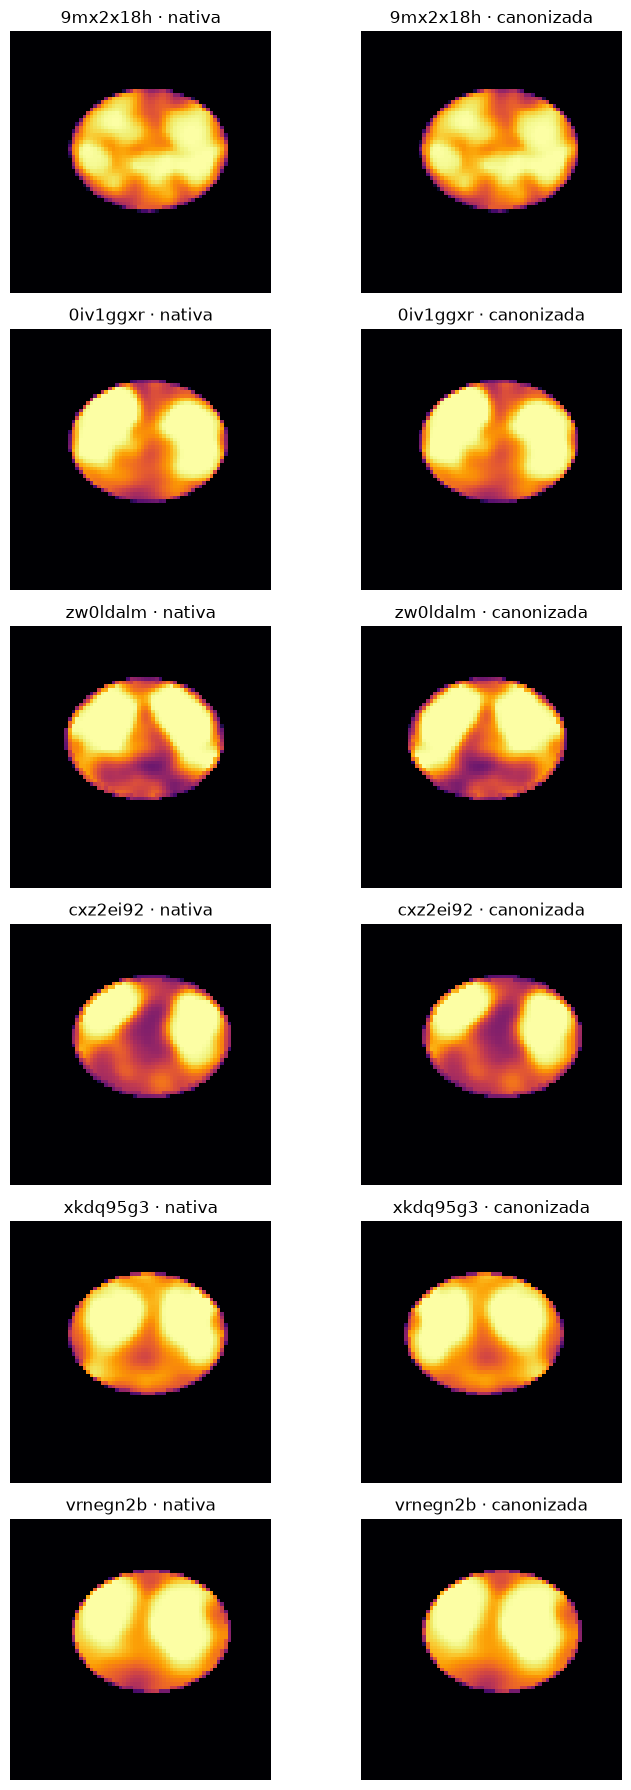

In [4]:
sample = prepared.cohort.sample(min(6, len(prepared.cohort)), random_state=EXPERIMENT.train.seed)
fig, axes = plt.subplots(len(sample), 2, figsize=(8, 3 * len(sample)))
axes = np.atleast_2d(axes)
for row_index, row in enumerate(sample.itertuples(index=False)):
    with np.load(row.base_cache_path, allow_pickle=False) as payload:
        native = payload["slab_native"].astype(np.float32)
        canonical = payload["slab_canonical"].astype(np.float32)
    for column, (image, title) in enumerate(((native, "nativa"), (canonical, "canonizada"))):
        axes[row_index, column].imshow(image, cmap="inferno")
        axes[row_index, column].set_title(f"{row.uid} · {title}")
        axes[row_index, column].axis("off")
plt.tight_layout()
plt.show()


## 3. Búsqueda compacta: tres folds

Cada trial completa sus tres folds balanceados por paciente. Optuna, los checkpoints por época, los bancos de plantillas y las 930 variables quedan persistidos; tras un corte se retoma el trial/época pendiente. La rama slab recibe el mayor presupuesto; 2.5D y 3D actúan como miembros diferentes del ensemble.


In [5]:
with RunLock(RUN_DIR / "search.lock"):
    search_result = run_search_stage(prepared, EXPERIMENT, device=DEVICE)
display(search_result.summary)


c:\Users\alana\OneDrive\Documentos\ChatGPT\DaT Scan\dat-parkinsons-challenge\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\alana\OneDrive\Documentos\ChatGPT\DaT Scan\dat-parkinsons-challenge\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-08-30 09:13:16,314] Using an existing study with name 'node07_slab2d_canonical_image_only' instead of creating a new one.
c:\Users\alana\OneDrive\Documentos\ChatGPT\DaT Scan\dat-parkinsons-challenge\.venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\alana\OneDrive\Documentos\ChatGPT\DaT Scan\dat-parkinsons-challenge\.venv\Lib\site-

[nodo07] fold=2 epoch=8/18 train=0.4803 val=0.5993
[nodo07] fold=2 epoch=9/18 train=0.4281 val=0.5912
[nodo07] fold=2 epoch=10/18 train=0.4579 val=0.6077
[nodo07] fold=2 epoch=11/18 train=0.4287 val=0.6174


[I 2026-08-30 09:19:16,705] Trial 2 finished with value: 0.551367391668287 and parameters: {'tabular_embedding_dim': 32, 'fusion_dropout': 0.29392301156981576, 'fusion_learning_rate': 0.00033108145371553525, 'fusion_weight_decay': 0.00016549961173900707, 'feature_top_k': 128, 'pca_variance': 'none'}. Best is trial 0 with value: 0.5446410849129827.
[I 2026-08-30 09:21:17,417] Trial 3 finished with value: 0.5446410849129827 and parameters: {'tabular_embedding_dim': 24, 'fusion_dropout': 0.30506770120532095, 'fusion_learning_rate': 0.00031707471417234434, 'fusion_weight_decay': 2.4852739935321194e-06, 'feature_top_k': 64, 'pca_variance': 'none'}. Best is trial 0 with value: 0.5446410849129827.
[I 2026-08-30 09:23:15,081] Trial 4 finished with value: 0.551367391668287 and parameters: {'tabular_embedding_dim': 32, 'fusion_dropout': 0.29392301156981576, 'fusion_learning_rate': 0.00033108145371553525, 'fusion_weight_decay': 0.00016549961173900707, 'feature_top_k': 128, 'pca_variance': 'none'}

[nodo07] fold=0 epoch=1/18 train=0.7259 val=0.6926
[nodo07] fold=0 epoch=2/18 train=0.7233 val=0.6940
[nodo07] fold=0 epoch=3/18 train=0.7217 val=0.6819
[nodo07] fold=0 epoch=4/18 train=0.7198 val=0.6944
[nodo07] fold=0 epoch=5/18 train=0.7139 val=0.6861
[nodo07] fold=0 epoch=6/18 train=0.6995 val=0.7118
[nodo07] fold=0 epoch=7/18 train=0.7122 val=0.6936
[nodo07] fold=0 epoch=8/18 train=0.7019 val=0.6605
[nodo07] fold=0 epoch=9/18 train=0.6970 val=0.6885
[nodo07] fold=0 epoch=10/18 train=0.6946 val=0.6609
[nodo07] fold=0 epoch=11/18 train=0.6916 val=0.6720
[nodo07] fold=0 epoch=12/18 train=0.6796 val=0.6596
[nodo07] fold=0 epoch=13/18 train=0.6720 val=0.6556
[nodo07] fold=0 epoch=14/18 train=0.6893 val=0.6484
[nodo07] fold=0 epoch=15/18 train=0.6890 val=0.6601
[nodo07] fold=0 epoch=16/18 train=0.6748 val=0.6618
[nodo07] fold=0 epoch=17/18 train=0.6782 val=0.6610
[nodo07] fold=0 epoch=18/18 train=0.6799 val=0.6611
[nodo07] fold=1 epoch=1/18 train=0.7273 val=0.6907
[nodo07] fold=1 epoch=

[I 2026-08-30 09:51:35,097] Trial 0 finished with value: 0.6621250294153439 and parameters: {'base_channels': 12, 'pooling': 'attention', 'dropout': 0.13662270001660687, 'augmentation_magnitude': 2.7687064255682854, 'augmentation_probability': 0.9046592369961097, 'rotation_degrees': 1.5143212869747387, 'learning_rate': 0.0002778747229336962, 'weight_decay': 6.082121595909291e-05, 'auxiliary_weight': 0.08998734149430038, 'consistency_weight': 0.06178994236617857}. Best is trial 0 with value: 0.6621250294153439.


...

[nodo07] fold=0 epoch=1/18 train=0.6913 val=0.5579
[nodo07] fold=0 epoch=2/18 train=0.6275 val=0.5242
[nodo07] fold=0 epoch=3/18 train=0.5889 val=0.5307
[nodo07] fold=0 epoch=4/18 train=0.5864 val=0.5243
[nodo07] fold=0 epoch=5/18 train=0.5714 val=0.5407
[nodo07] fold=0 epoch=6/18 train=0.5423 val=0.5457
[nodo07] fold=0 epoch=7/18 train=0.5244 val=0.5402
[nodo07] fold=1 epoch=1/18 train=0.6773 val=0.6063
[nodo07] fold=1 epoch=2/18 train=0.5896 val=0.6541
[nodo07] fold=1 epoch=3/18 train=0.5993 val=0.6131
[nodo07] fold=1 epoch=4/18 train=0.5209 val=0.6474
[nodo07] fold=1 epoch=5/18 train=0.5863 val=0.6077
[nodo07] fold=1 epoch=6/18 train=0.5386 val=0.6859
[nodo07] fold=2 epoch=1/18 train=0.7042 val=0.5879
[nodo07] fold=2 epoch=2/18 train=0.6269 val=0.6012
[nodo07] fold=2 epoch=3/18 train=0.6188 val=0.5777
[nodo07] fold=2 epoch=4/18 train=0.5705 val=0.6147
[nodo07] fold=2 epoch=5/18 train=0.5811 val=0.6827
[nodo07] fold=2 epoch=6/18 train=0.5852 val=0.6044
[nodo07] fold=2 epoch=7/18 trai

[I 2026-08-30 21:50:30,267] Trial 0 finished with value: 0.5694060264934299 and parameters: {'tabular_embedding_dim': 24, 'fusion_dropout': 0.30506770120532095, 'fusion_learning_rate': 0.00031707471417234434, 'fusion_weight_decay': 2.4852739935321194e-06, 'feature_top_k': 64, 'pca_variance': 'none'}. Best is trial 0 with value: 0.5694060264934299.


[nodo07] fold=0 epoch=1/18 train=0.6843 val=0.5347
[nodo07] fold=0 epoch=2/18 train=0.6073 val=0.5373
[nodo07] fold=0 epoch=3/18 train=0.5904 val=0.5170
[nodo07] fold=0 epoch=4/18 train=0.5633 val=0.5215
[nodo07] fold=0 epoch=5/18 train=0.5545 val=0.5284
[nodo07] fold=0 epoch=6/18 train=0.5208 val=0.5166
[nodo07] fold=0 epoch=7/18 train=0.4532 val=0.5771
[nodo07] fold=0 epoch=8/18 train=0.4621 val=0.5788
[nodo07] fold=0 epoch=9/18 train=0.4426 val=0.6092
[nodo07] fold=0 epoch=10/18 train=0.4339 val=0.6426
[nodo07] fold=0 epoch=11/18 train=nan val=0.6327
[nodo07] fold=1 epoch=1/18 train=0.6510 val=0.6482
[nodo07] fold=1 epoch=2/18 train=0.5764 val=0.6801
[nodo07] fold=1 epoch=3/18 train=0.5556 val=0.6238
[nodo07] fold=1 epoch=4/18 train=0.4722 val=0.6814
[nodo07] fold=1 epoch=5/18 train=0.5218 val=0.7014
[nodo07] fold=1 epoch=6/18 train=0.4570 val=0.7581
[nodo07] fold=1 epoch=7/18 train=0.4721 val=0.6910
[nodo07] fold=1 epoch=8/18 train=0.4289 val=0.7872
[nodo07] fold=2 epoch=1/18 train

[I 2026-08-30 22:04:01,979] Trial 1 finished with value: 0.5712537083919504 and parameters: {'tabular_embedding_dim': 32, 'fusion_dropout': 0.29392301156981576, 'fusion_learning_rate': 0.00033108145371553525, 'fusion_weight_decay': 0.00016549961173900707, 'feature_top_k': 128, 'pca_variance': 'none'}. Best is trial 0 with value: 0.5694060264934299.


,study_name,architecture,feature_variant,lateral_strategy,search_log_loss,fixed_epochs,candidate_id,is_finalist
0,node07_25d_random_flip_image_radiomics_sbr,2.5d,image_radiomics_sbr,random_flip,0.536516,9,fb93ea204b0ec32f,True
1,node07_slab2d_random_flip_image_radiomics_sbr,slab2d,image_radiomics_sbr,random_flip,0.544641,9,23f042f62f40d03e,True
2,node07_slab2d_canonical_image_radiomics_sbr,slab2d,image_radiomics_sbr,canonical,0.545231,9,10443743d6b351fb,False
3,node07_slab2d_random_flip_image_radiomics,slab2d,image_radiomics,random_flip,0.548583,9,b6ed410231aa7c42,False
4,node07_25d_canonical_image_radiomics,2.5d,image_radiomics,canonical,0.551357,9,49a7cd76109a316e,False
5,node07_25d_canonical_image_radiomics_sbr,2.5d,image_radiomics_sbr,canonical,0.551413,9,4cec60eb94de1db3,False
6,node07_25d_random_flip_image_radiomics,2.5d,image_radiomics,random_flip,0.551462,9,7940dcb4fa2c2dfb,False
7,node07_slab2d_canonical_image_radiomics,slab2d,image_radiomics,canonical,0.551590,9,2cd0bb16d485ad80,False
8,node07_3d_random_flip_image_radiomics_sbr,3d,image_radiomics_sbr,random_flip,0.569406,3,3f9bbf24164bd1dc,True
9,node07_3d_canonical_image_radiomics_sbr,3d,image_radiomics_sbr,canonical,0.574206,3,267695ca4cd22012,False


## 4. Evaluación final: cinco folds congelados

Se reentrenan dos o tres finalistas durante el número de épocas decidido en la búsqueda. No se usa el fold externo para early stopping. La selección final emplea log loss OOF calibrado de forma cruzada.


In [6]:
with RunLock(RUN_DIR / "final.lock"):
    final_result = run_final_stage(prepared, EXPERIMENT, device=DEVICE)
display(final_result.metrics)
display(Markdown(
    f"**Modelo primario:** `{final_result.deployment_manifest['primary_candidate_id']}` · "
    f"**modelos por fold:** `{final_result.deployment_manifest['n_fold_models']}`"
))


[nodo07 multitemplate fold=0] 25/1362
[nodo07 multitemplate fold=0] 50/1362
[nodo07 multitemplate fold=0] 75/1362
[nodo07 multitemplate fold=0] 100/1362
[nodo07 multitemplate fold=0] 125/1362
[nodo07 multitemplate fold=0] 150/1362
[nodo07 multitemplate fold=0] 175/1362
[nodo07 multitemplate fold=0] 200/1362
[nodo07 multitemplate fold=0] 225/1362
[nodo07 multitemplate fold=0] 250/1362
[nodo07 multitemplate fold=0] 275/1362
[nodo07 multitemplate fold=0] 300/1362
[nodo07 multitemplate fold=0] 325/1362
[nodo07 multitemplate fold=0] 350/1362
[nodo07 multitemplate fold=0] 375/1362
[nodo07 multitemplate fold=0] 400/1362
[nodo07 multitemplate fold=0] 425/1362
[nodo07 multitemplate fold=0] 450/1362
[nodo07 multitemplate fold=0] 475/1362
[nodo07 multitemplate fold=0] 500/1362
[nodo07 multitemplate fold=0] 525/1362
[nodo07 multitemplate fold=0] 550/1362
[nodo07 multitemplate fold=0] 575/1362
[nodo07 multitemplate fold=0] 600/1362
[nodo07 multitemplate fold=0] 625/1362
[nodo07 multitemplate fold=0

,candidate_id,architecture,feature_variant,lateral_strategy,raw_log_loss,raw_brier,raw_auc,raw_balanced_accuracy_0_5,raw_ece_10,calibrated_log_loss,calibrated_brier,calibrated_auc,calibrated_balanced_accuracy_0_5,calibrated_ece_10,deployment_temperature
0,23f042f62f40d03e,slab2d,image_radiomics_sbr,random_flip,0.556924,0.187166,0.799906,0.735958,0.064860,0.551498,0.184972,0.796822,0.735958,0.045810,1.266840
1,fb93ea204b0ec32f,2.5d,image_radiomics_sbr,random_flip,0.560599,0.187826,0.797649,0.739593,0.071564,0.552242,0.184982,0.793100,0.739593,0.043068,1.333065
2,3f9bbf24164bd1dc,3d,image_radiomics_sbr,random_flip,0.586020,0.195744,0.780836,0.727110,0.087526,0.565622,0.190079,0.775836,0.727110,0.029703,1.508521


**Modelo primario:** `23f042f62f40d03e` · **modelos por fold:** `5`

## 5. Artefactos y lectura honesta

- `outputs/private_eda/node07_cache/`: derivados físicos, plantillas y features reanudables.
- `outputs/private_eda/node07_runs/<run_id>/search/`: SQLite de Optuna, trials y finalistas.
- `outputs/private_eda/node07_runs/<run_id>/final/`: OOF, métricas, calibración y cinco checkpoints del modelo primario.

La arquitectura sólo se promueve sobre el nodo 06 si mejora log loss OOF, calibración, estabilidad entre folds y peor familia de adquisición. La separación visual de embeddings no es criterio de selección.
